In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from collections import defaultdict
import math

In [33]:
paths = glob.glob("patterns_padded/*.png")
imgs = {}
notes = cv2.imread("trimed.png", cv2.IMREAD_GRAYSCALE)

for path in paths:
    name = os.path.basename(path).split(".")[0]
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    imgs[name] = img


In [34]:
def get_reference_point(img):
    """
    Oblicza środek ciężkości (centroid) obrazu za pomocą momentów geometrycznych.
    Wymaga, aby symbol był biały na czarnym tle.
    """
    M = cv2.moments(img)
    
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = img.shape[1] // 2, img.shape[0] // 2
        
    return int(cX), int(cY)

def build_r_table(img, num_angle_bins=360):
    """
    Buduje R-tablicę dla pojedynczego wzorca.
    """
    ref_x, ref_y = get_reference_point(img)
    edges = cv2.Canny(img, 50, 150)

    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    _, angles = cv2.cartToPolar(sobel_x, sobel_y, angleInDegrees=True)

    r_table = defaultdict(list)

    edge_points = np.argwhere(edges > 0)

    for y, x in edge_points:
        angle = angles[y, x]
        
        angle_bin = int(angle) % num_angle_bins

        dx = ref_x - x
        dy = ref_y - y

        r_table[angle_bin].append((dx, dy))

    return r_table, (ref_x, ref_y)

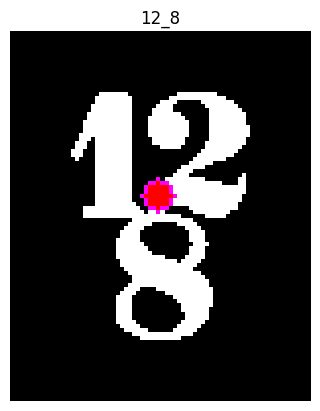

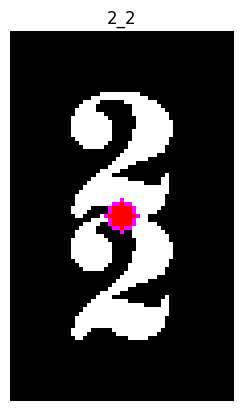

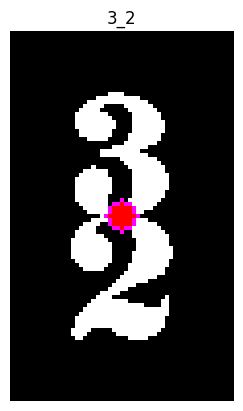

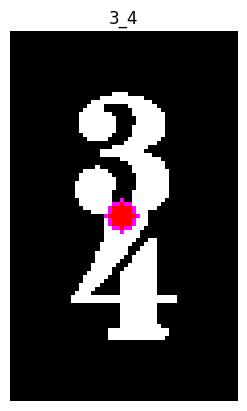

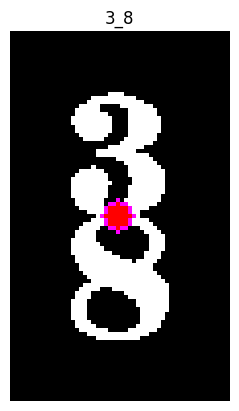

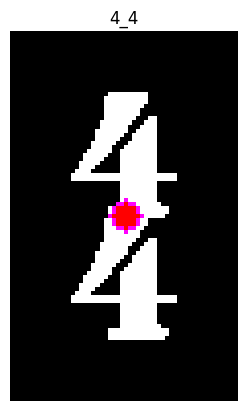

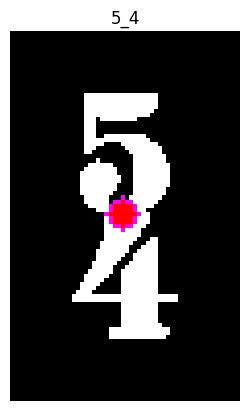

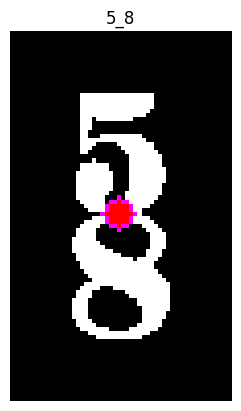

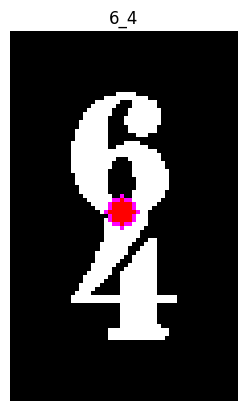

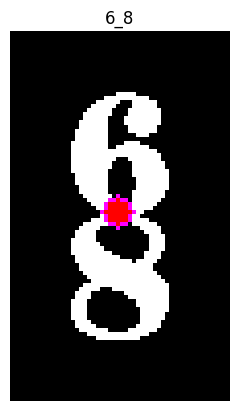

In [35]:
for key in list(imgs.keys())[:10]:
    r_table, (cX, cY) = build_r_table(imgs[key])
    copy = imgs[key].copy()
    copy_rgb = cv2.cvtColor(copy, cv2.COLOR_GRAY2RGB)

    cv2.circle(copy_rgb, (cX, cY), radius=3, color=(255, 0, 0), thickness=-1)
    cv2.circle(copy_rgb, (cX, cY), radius=4, color=(255, 0, 255), thickness=1)

    plt.imshow(copy_rgb)
    plt.title(key)
    plt.axis('off')
    plt.show()

In [36]:
r_table = {}
for key, img in imgs.items():
    r_tab, ref_point = build_r_table(img)
    r_table[key] = {"table": r_tab, "ref_point": ref_point}



In [37]:
def detect_pattern_ght(score_img, r_table_data, threshold_ratio=0.7):
    """
    Wykonuje głosowanie GHT dla jednego wzorca na podanym obrazie.
    
    :param score_img: Obraz partytury (w skali szarości).
    :param r_table_data: Słownik zawierający 'table' (R-tablicę).
    :param threshold_ratio: Próg odcięcia (0.0 do 1.0) względem maksymalnej liczby głosów.
    :return: Lista współrzędnych (x, y) wykrytych obiektów oraz macierz Akumulatora.
    """
    r_table = r_table_data["table"]
    height, width = score_img.shape
    
    edges = cv2.Canny(score_img, 50, 150)
    sobel_x = cv2.Sobel(score_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(score_img, cv2.CV_64F, 0, 1, ksize=3)
    
    _, angles = cv2.cartToPolar(sobel_x, sobel_y, angleInDegrees=True)
    
    accumulator = np.zeros((height, width), dtype=np.int32)
    
    edge_points = np.argwhere(edges > 0)
    
    # Właściwe Głosowanie
    for y, x in edge_points:
        angle_bin = int(angles[y, x]) % 360
        
        # Jeśli ten kąt krawędzi występuje w R-tablicy wzorca
        # Można by tu dodać nagle_offset (angle_offset in [-2,-1,0, 1,2]) dla większej tolerancji
        if angle_bin in r_table:
            # przejdź przez wszystkie wektory do środka ciężkości
            for dx, dy in r_table[angle_bin]:
                # Wylicz przewidywany środek ciężkości na partyturze
                ref_x = x + dx
                ref_y = y + dy
                
                if 0 <= ref_x < width and 0 <= ref_y < height:
                    accumulator[ref_y, ref_x] += 1
                    
    # 4. Szukanie "pików" (lokalnych maksimów)
    max_votes = np.max(accumulator)
    if max_votes == 0:
        return [], accumulator
        
    # Akceptujemy tylko te punkty, które zebrały odpowiednio dużo głosów
    thresh_value = max_votes * threshold_ratio
    peaks_y, peaks_x = np.where(accumulator >= thresh_value)
    
    detections = list(zip(peaks_x, peaks_y))
    
    return detections, accumulator

In [38]:
def apply_nms(detections, min_distance):
    """
    Wykonuje Non-Maximum Suppression na punktach.
    
    :param detections: Lista krotek w formacie (x, y, liczba_glosow, skala)
    :param min_distance: Promień (w pikselach), w którym ignorujemy słabsze punkty.
                         Powinien wynosić mniej więcej połowę szerokości Twojego wzorca.
    :return: Przefiltrowana lista krotek (najlepsze wykrycia).
    """
    # Sortujemy malejąco według liczby głosów (indeks 2 w krotce)
    sorted_detections = sorted(detections, key=lambda d: d[2], reverse=True)
    
    final_detections = []
    
    while len(sorted_detections) > 0:
        # 1. Bierzemy najlepszy punkt z aktualnej listy
        best_point = sorted_detections.pop(0)
        final_detections.append(best_point)
        
        # 2. Tworzymy nową listę, zatrzymując tylko te punkty, które są daleko
        filtered_detections = []
        for point in sorted_detections:
            # Obliczamy odległość euklidesową (Pitagoras)
            dist = math.hypot(best_point[0] - point[0], best_point[1] - point[1])
            
            # Jeśli punkt jest dalej niż nasz promień, zostawiamy go do dalszej analizy
            if dist >= min_distance:
                filtered_detections.append(point)
                
        # 3. Zastępujemy starą listę nową, przefiltrowaną
        sorted_detections = filtered_detections
        
    return final_detections

In [39]:
def visualize_ght_results(score_img, accumulator, detections, pattern_name="Wzorzec"):
    """
    Wyświetla wyniki głosowania: oryginalny obraz z detekcjami oraz mapę cieplną akumulatora.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    img_color = cv2.cvtColor(score_img, cv2.COLOR_GRAY2RGB)
    
    for x, y in detections:
        # Rysujemy małe, czerwone kółka w wytypowanych środkach ciężkości
        cv2.circle(img_color, (x, y), radius=2, color=(255, 0, 0), thickness=-1)

    ax1.imshow(img_color)
    ax1.set_title(f"Detekcje: {pattern_name} (Zgrupowane punkty: {len(detections)})")
    ax1.axis('off')

    # --- Panel 2: Mapa cieplna Akumulatora ---
    # Używamy mapy 'hot' (czarny -> czerwony -> żółty -> biały dla maksimów)
    im = ax2.imshow(accumulator, cmap='hot')
    ax2.set_title("Przestrzeń Akumulatora (Natężenie głosów)")
    ax2.axis('off')
    
    # Dodajemy pasek skali z boku, żeby widzieć, ile wynosiła maksymalna liczba głosów
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label="Liczba głosów")

    plt.tight_layout()
    plt.show()

Szukam wzorca: clef_treble...
Przeszukiwanie w skali: 80.0%


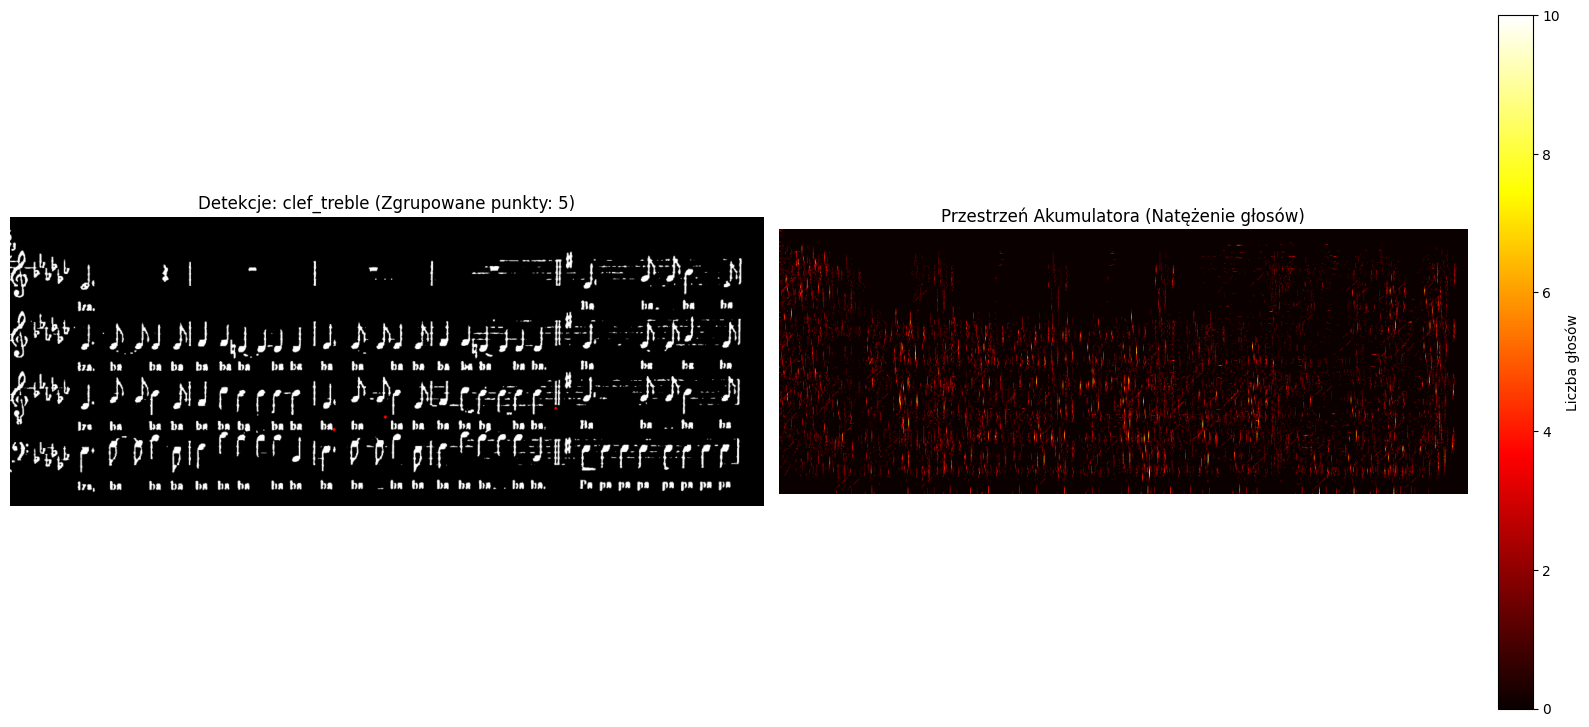

Przeszukiwanie w skali: 90.0%


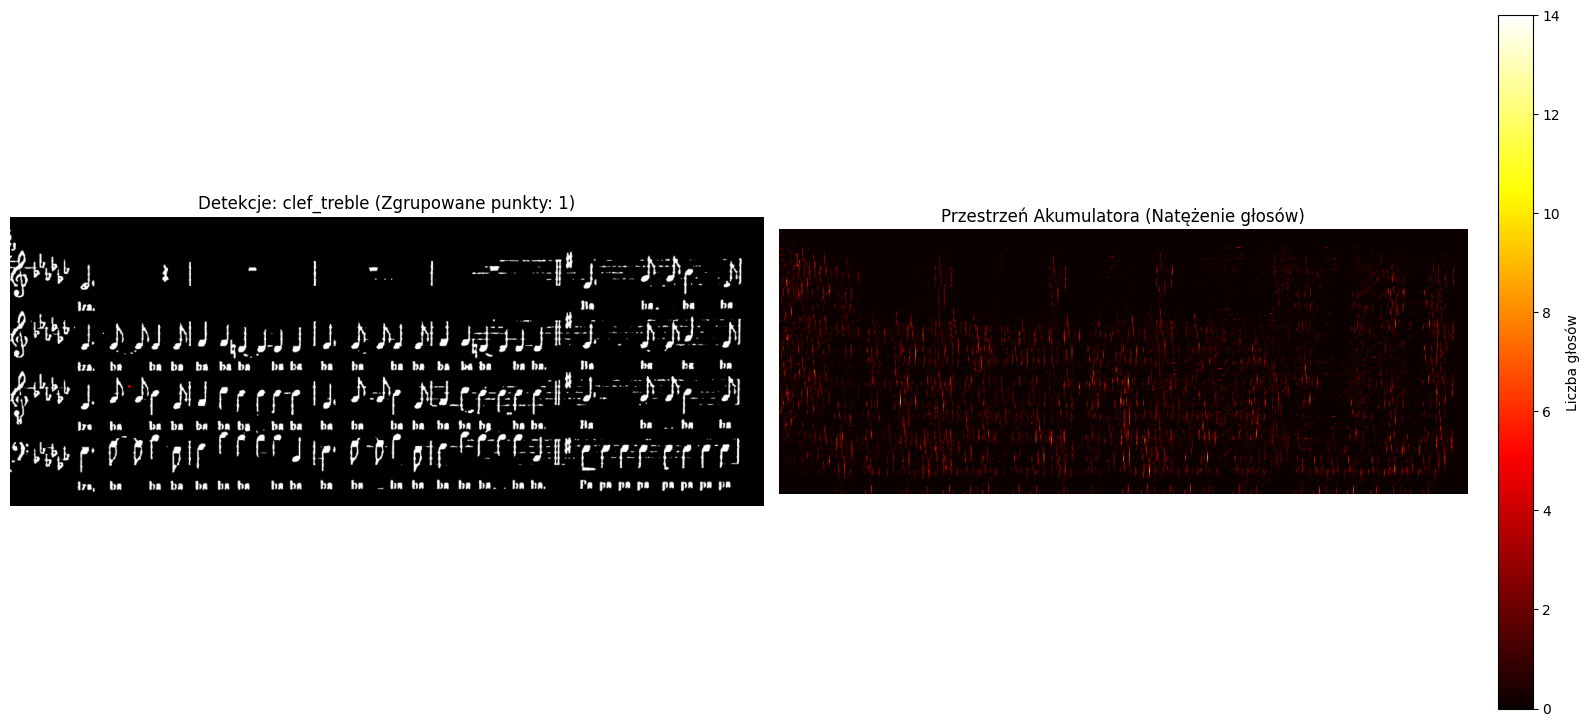

Przeszukiwanie w skali: 100.0%


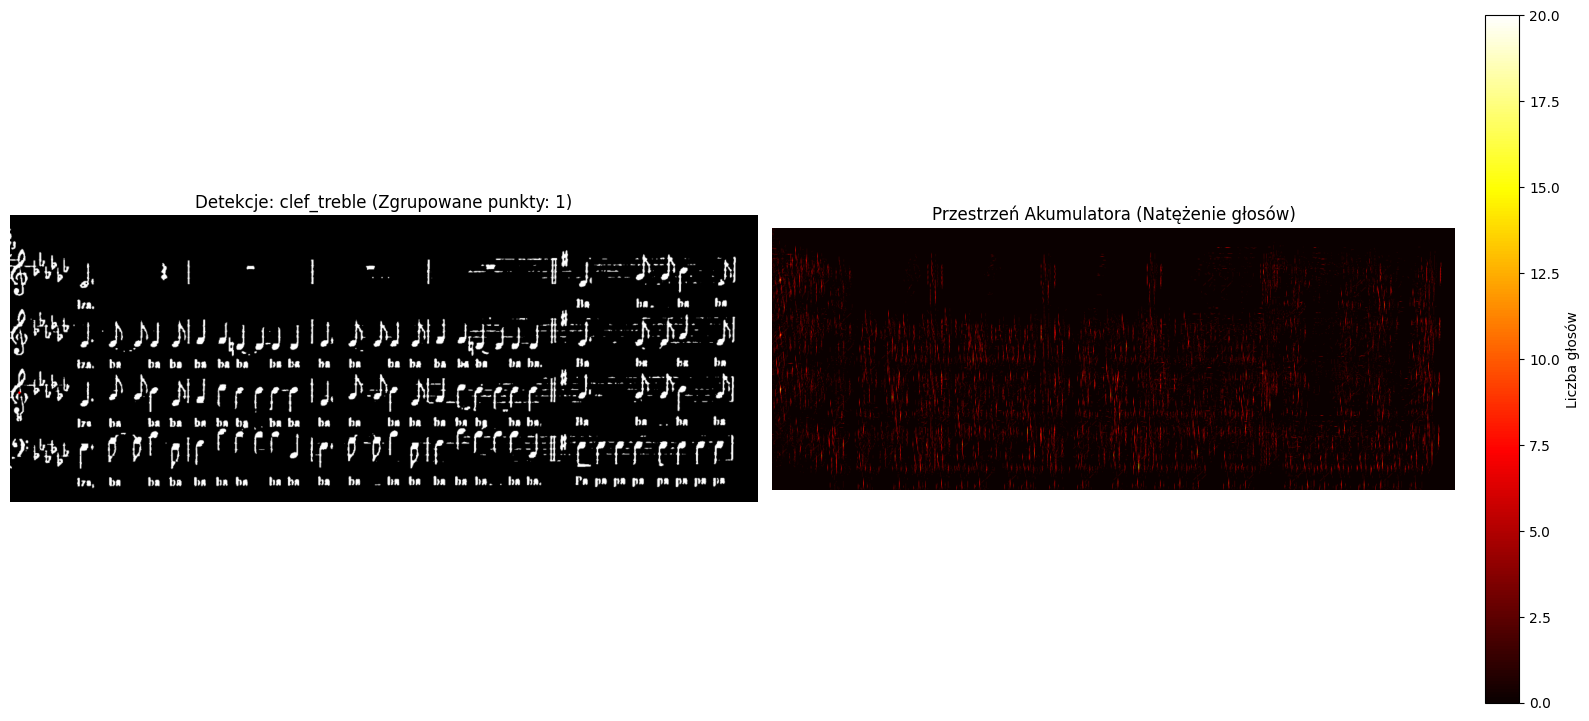

Przeszukiwanie w skali: 110.00000000000001%


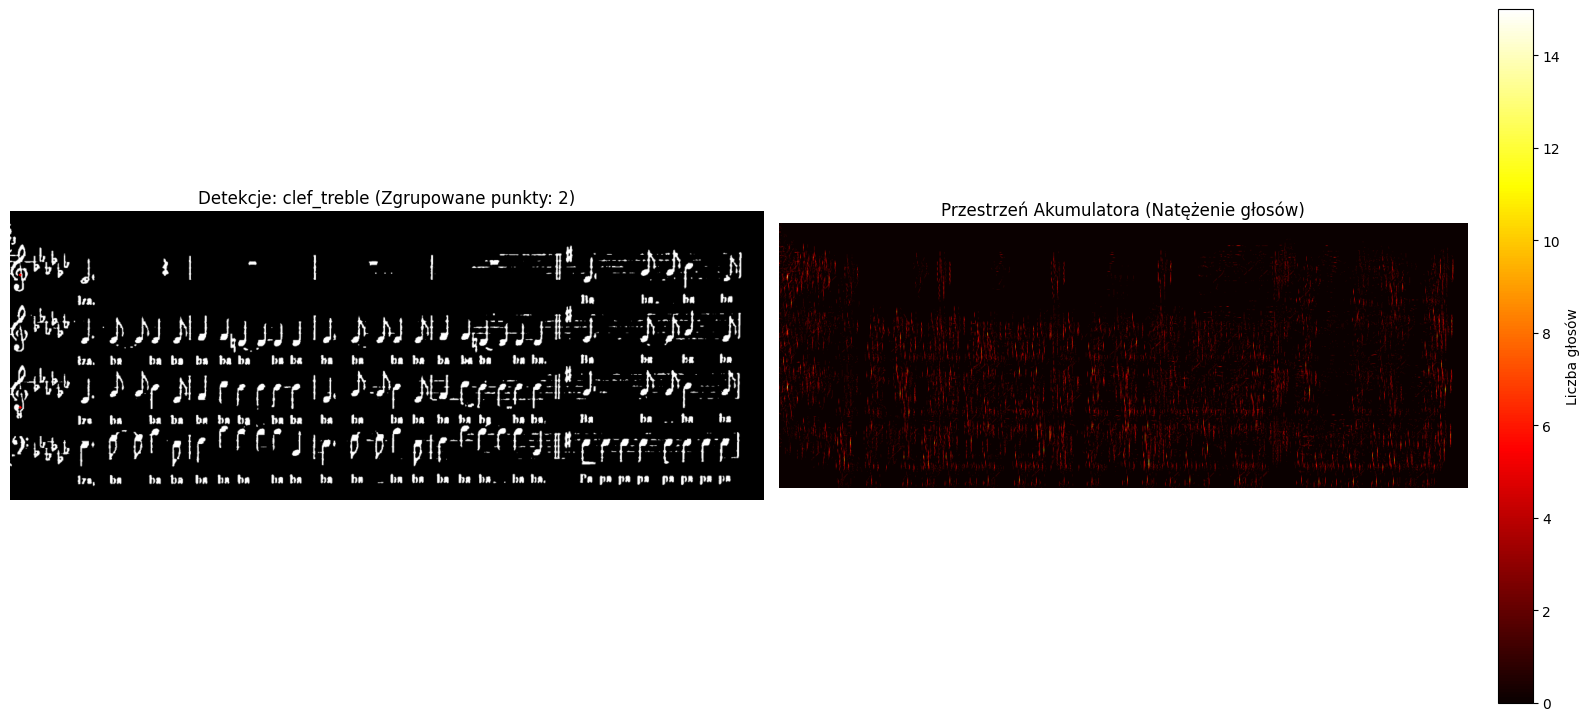

Przeszukiwanie w skali: 120.0%


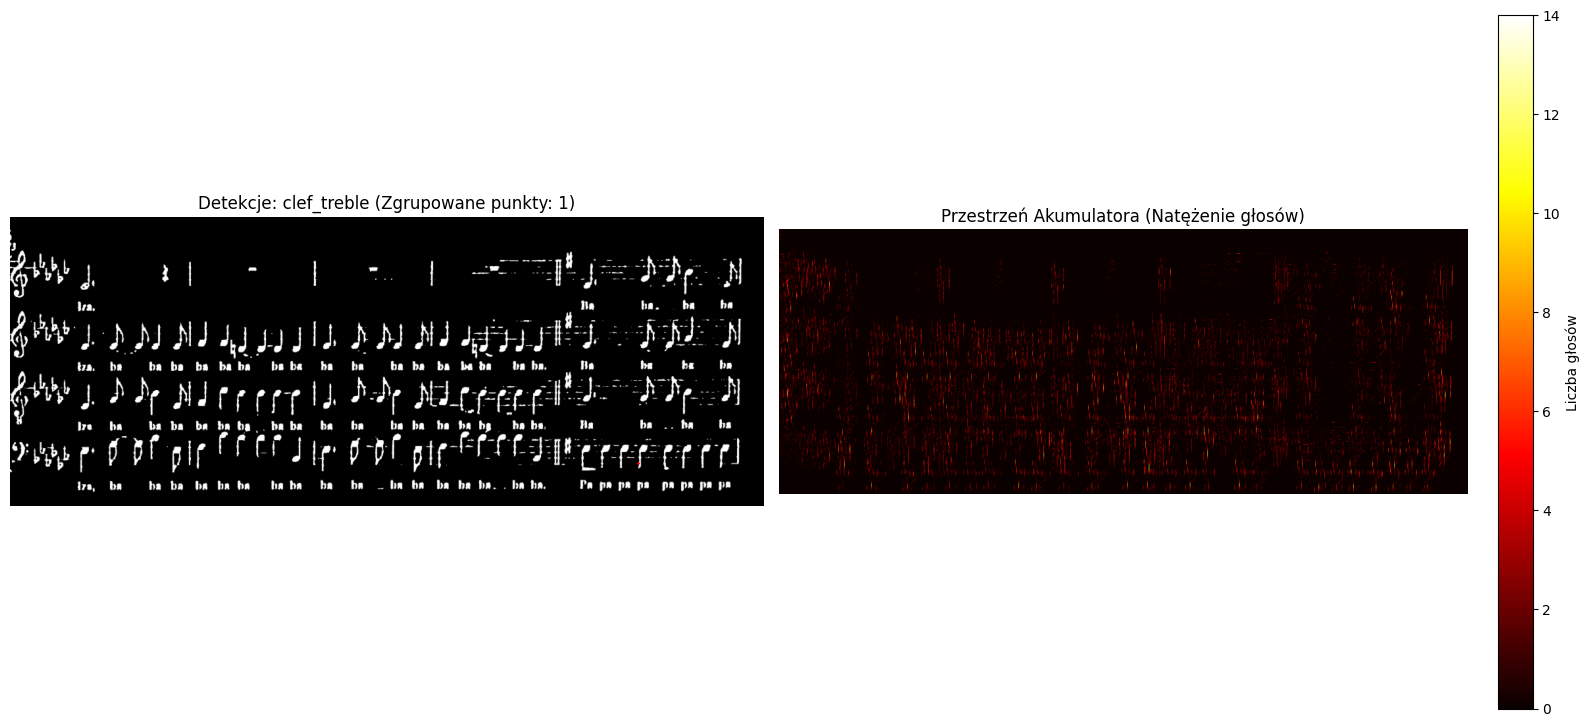

Łącznie znaleziono 10 potencjalnych punktów.


In [43]:
target_pattern_name = "clef_treble" 
pattern_data = r_table[target_pattern_name]

print(f"Szukam wzorca: {target_pattern_name}...")

scales = [0.8, 0.9, 1.0, 1.1, 1.2,]
all_detections = []

for scale in scales:
    print(f"Przeszukiwanie w skali: {scale * 100}%")
    
    # Zmiana rozmiaru partytury
    new_width = int(notes.shape[1] * scale)
    new_height = int(notes.shape[0] * scale)
    resized_notes = cv2.resize(notes, (new_width, new_height))
    
    # Uruchomienie GHT na zeskalowanym obrazku
    detections, accumulator = detect_pattern_ght(resized_notes, pattern_data, threshold_ratio=0.95)

    visualize_ght_results(notes, accumulator, detections, target_pattern_name)
    
    # Musimy przeskalować wykryte punkty z powrotem do oryginalnego rozmiaru notes.png
    for x, y in detections:
        original_x = int(x / scale)
        original_y = int(y / scale)
        score = accumulator[y, x]
        all_detections.append((original_x, original_y, score, scale))

print(f"Łącznie znaleziono {len(all_detections)} potencjalnych punktów.")

In [41]:
def visualize_final_results(score_img, final_detections, pattern_name="Wzorzec"):
    """
    Wyświetla ostateczne, odfiltrowane przez NMS punkty na oryginalnej partyturze.
    """
    img_color = cv2.cvtColor(score_img, cv2.COLOR_GRAY2RGB)
    
    for x, y, score, scale in final_detections:
        cv2.circle(img_color, (x, y), radius=15, color=(0, 255, 0), thickness=2)
        
        cv2.circle(img_color, (x, y), radius=3, color=(255, 0, 0), thickness=-1)
        
        label = f"{int(scale*100)}%"
        cv2.putText(
            img_color, label, (x + 18, y + 5), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2
        )

    plt.figure(figsize=(16, 10))
    plt.imshow(img_color)
    plt.title(f"Końcowe detekcje po NMS: {pattern_name} (Znaleziono: {len(final_detections)} szt.)")
    plt.axis('off')
    plt.show()

182.4
Po NMS: Zostało 6 unikalnych obiektów.


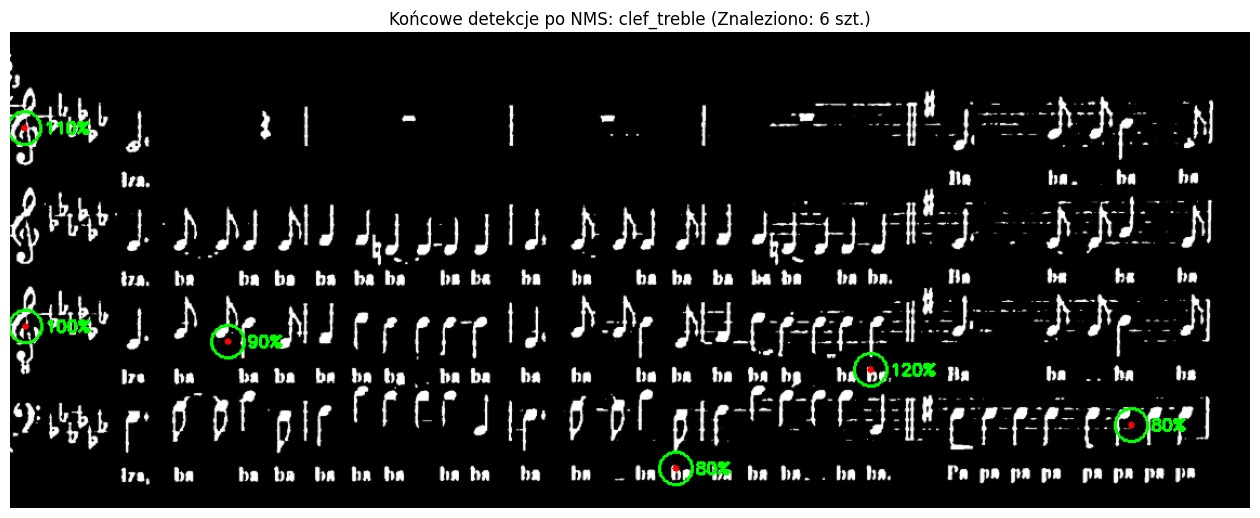

In [53]:
min_dist_pixels = imgs["clef_treble"].shape[1] * 3.2
print(min_dist_pixels)
final_best_detections = apply_nms(all_detections, min_distance=min_dist_pixels)

print(f"Po NMS: Zostało {len(final_best_detections)} unikalnych obiektów.")
visualize_final_results(notes, final_best_detections, target_pattern_name)